In [1]:
using SpecialFunctions
using LinearAlgebra
using CSV, DataFrames, Plots, LaTeXStrings
using Statistics
using Measures
using TensorOperations
include("module_graphene.jl")
using .exciton
using Printf

In [2]:
color_list_for_plot = [
    RGB(0.0, 0.45, 0.74),   
    RGB(0.2, 0.2, 0.5),     
    :red,
    :orange,
    RGB(0.55, 0.35, 0.2)   
]

marker_list_for_plot = [:circle,  
    :circle,
    :utriangle, 
    :dtriangle,  
    :diamond]

5-element Vector{Symbol}:
 :circle
 :circle
 :utriangle
 :dtriangle
 :diamond

# Fig 2a

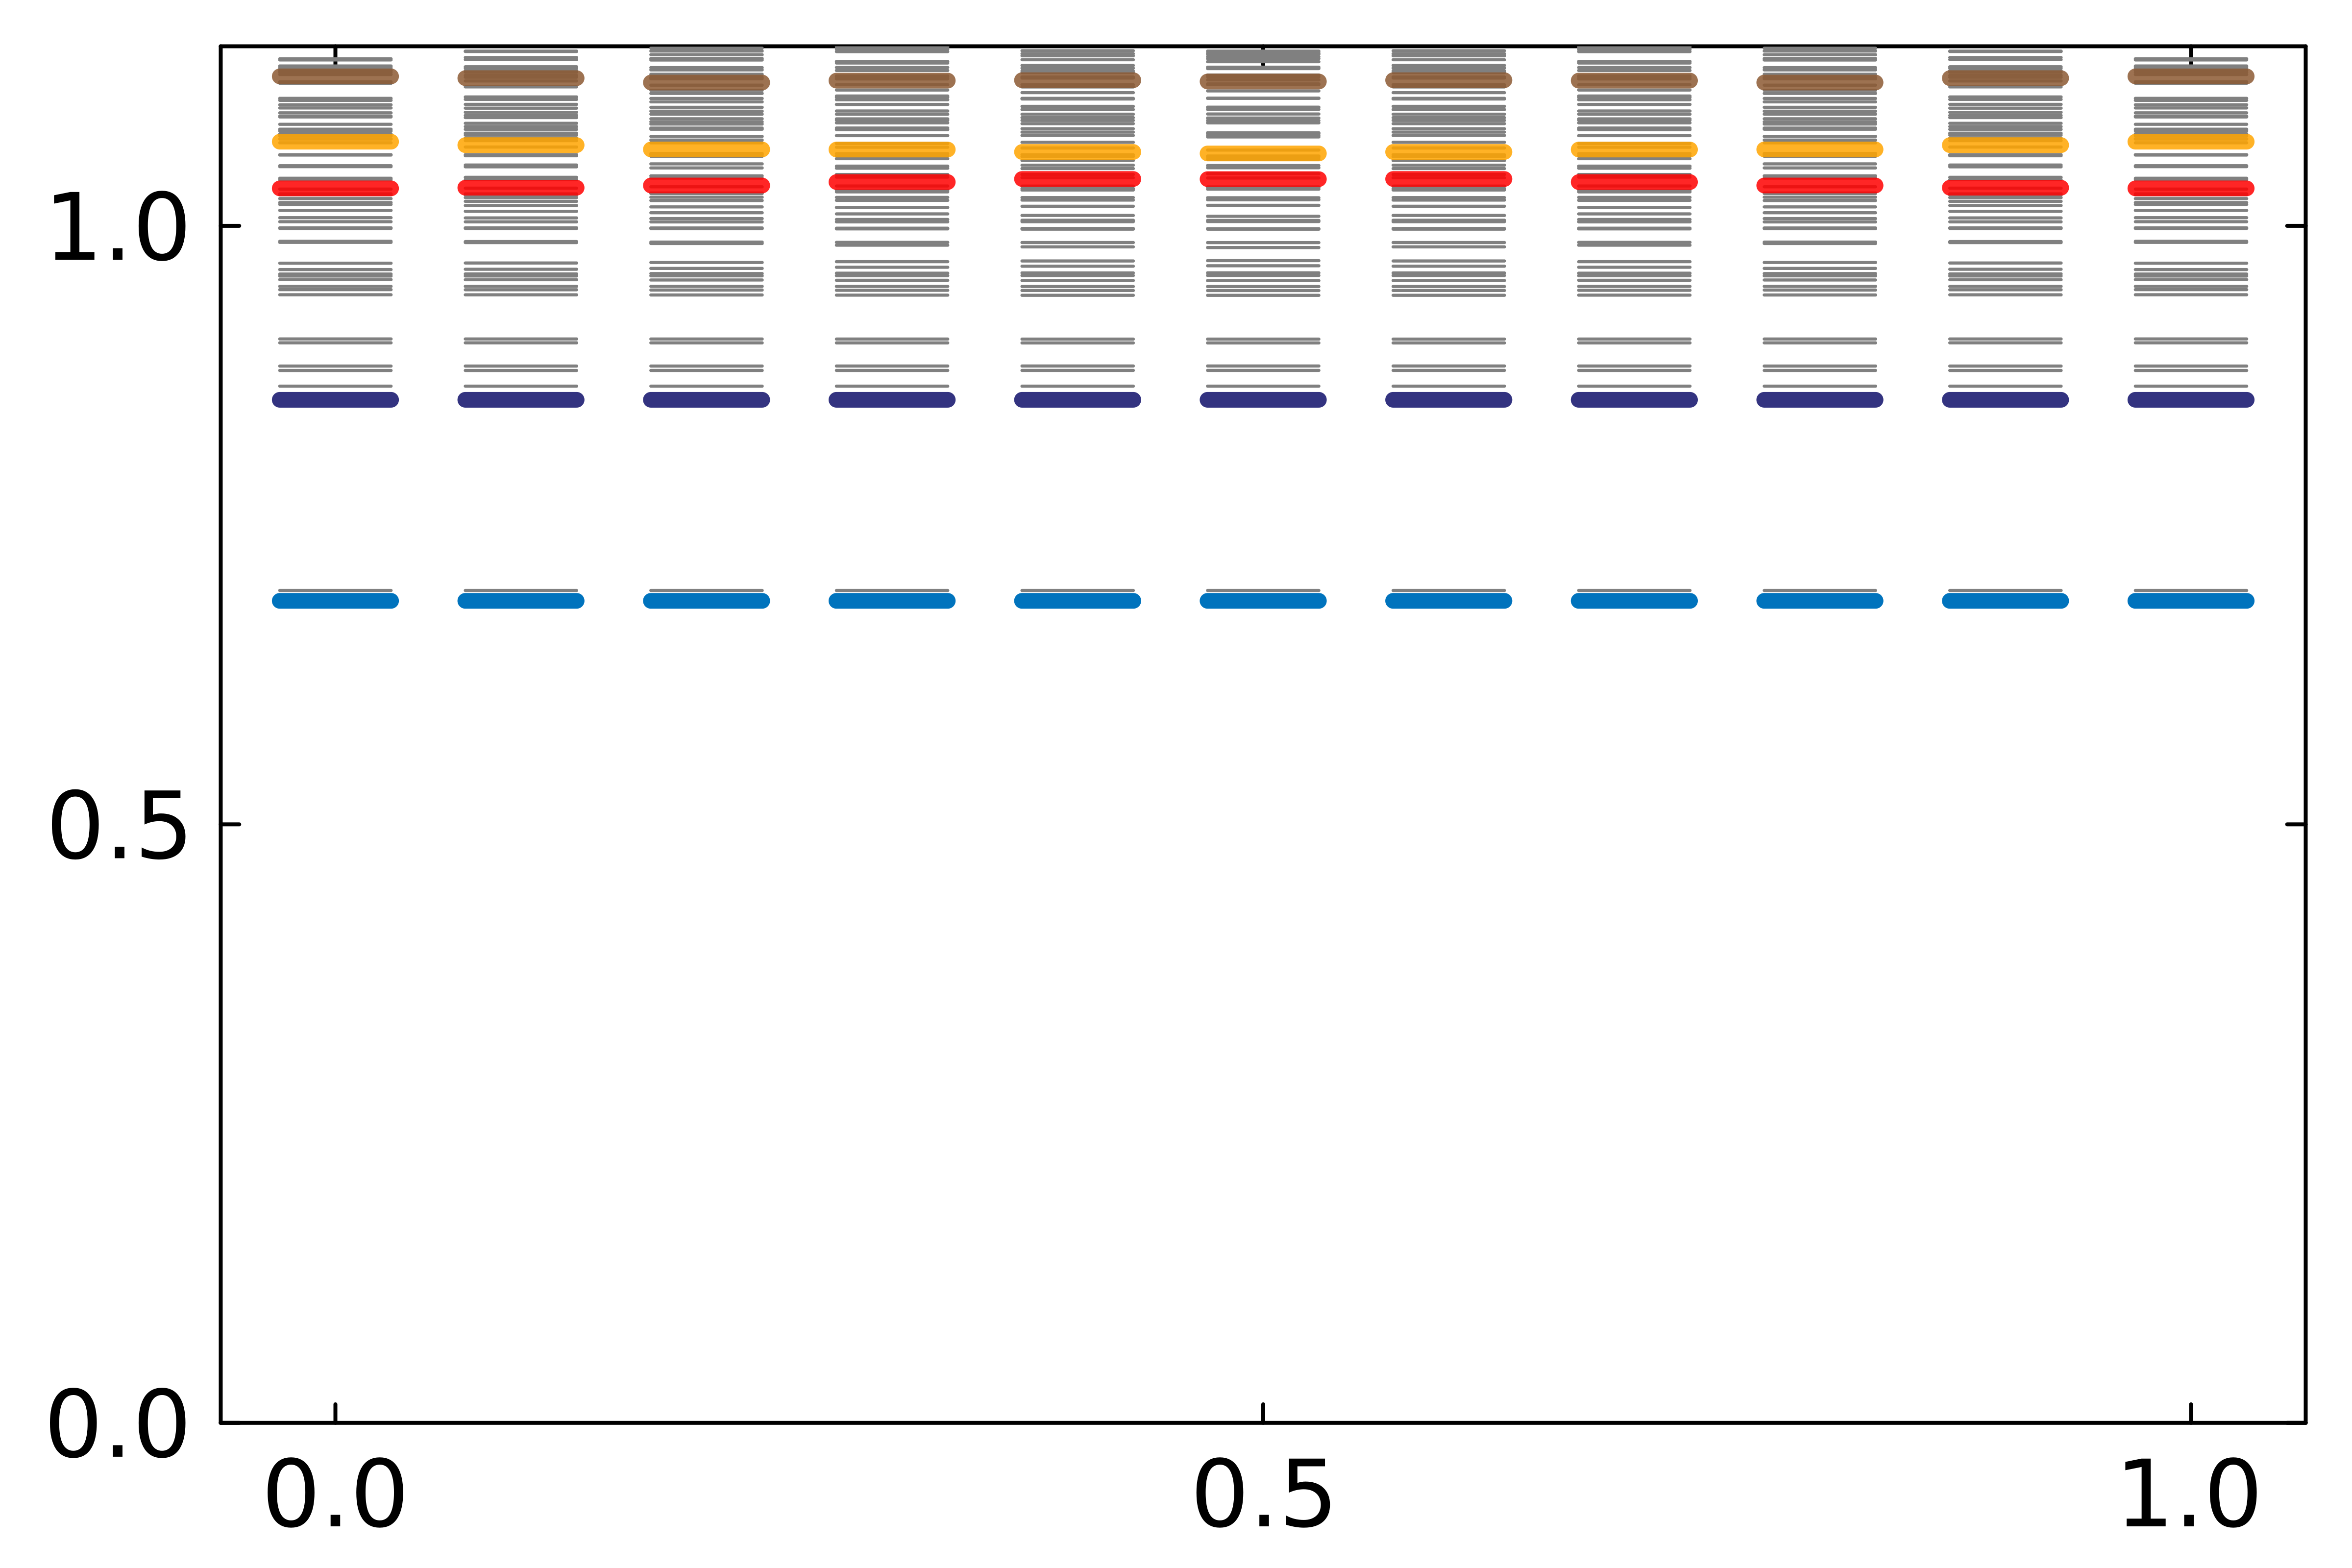

"/Users/xuyang/numerical_library/github/exciton/src/fig2/fig2a.pdf"

In [3]:
df = CSV.read("fig2a.csv", DataFrame)

alphalist = 0.0:0.1:1.0
eigenvalue_number = 80
energy_list = zeros(Float64, length(alphalist), eigenvalue_number)

for i in 0:10
    col = @sprintf("%.1f", i/10)   # ensures "0.0", "0.1", ..., "1.0"
    energy_list[i+1, :] = df[:, col]
end

windowrange = (0.0, 1.15)
offset = count(<(1), energy_list[1, :])

# Setup
x_values = 0.0:0.1:1.0
line_length = 0.06
delocalized_list = [10, 18, 35] # above gap

de1, de2, de3 = offset .+ delocalized_list
highlight_map = Dict(de1 => color_list_for_plot[3], de2 => color_list_for_plot[4], de3 => color_list_for_plot[5])

# Plot attributes
plot_attrs = Dict(
    :xgrid => false, :ygrid => false, :framestyle => :box,
    :xticks => ([0, 0.5, 1.0], [0, 0.5, 1.0]),
    :yticks => ([0, 0.5, 1.0, 1.5], [0, 0.5, 1.0, 1.5]),
    :tickfontsize => 16,
    :xlabelfontsize => 18,
    :ylabelfontsize => 18,
    :dpi => 800,
    :ylims => windowrange
)


function draw_lines!(x_vals, y_vals; lw=1.3, color=:grey, alphaval=1, attrs=Dict())
    for (x, y) in zip(x_vals, y_vals)
        plot!([x - line_length / 2, x + line_length / 2], [y, y];
            lw=lw, color=color, label=false, alpha=alphaval, attrs...)
    end
end


p = plot()

# Plot rows 2:80, with exceptions for highlighted ones
for row in 2:80
    if row != 3
        y_vals = real(energy_list)[:, row]
        if !haskey(highlight_map, row)
            draw_lines!(x_values, y_vals; lw=0.8, color=:grey, attrs=plot_attrs)
        end
    end
end

for row in 2:80
    if row != 3
        y_vals = real(energy_list)[:, row]
        if haskey(highlight_map, row)
            draw_lines!(x_values, y_vals; lw=4, color=highlight_map[row], alphaval=0.85, attrs=plot_attrs)
        end
    end
end

# Plot the blue curve (row = 1)
for row = 1:2
    y_vals = real(energy_list)[:, 2*row-1]
    draw_lines!(x_values, y_vals; lw=4, color=color_list_for_plot[row], attrs=plot_attrs)
end


display(p)
savefig("fig2a.pdf")

# Fig 2ainset

In [4]:
df = CSV.read("fig2a_inset.csv", DataFrame)

Nsample_list = df.size

ET_list = zeros(Float64, length(Nsample_list), 5)
ET_list[:,1] = df.localized_1
ET_list[:,2] = df.localized_2
ET_list[:,3] = df.delocalized_1;
ET_list[:,4] = df.delocalized_2;
ET_list[:,5] = df.delocalized_3;

# Plot exciton Thouless number
thoulessplot = scatter(Nsample_list[1:end], abs.(ET_list[1:end, 1]), yscale=:log10,
    lw=2,
    color=color_list_for_plot[1], framestyle=:box,
    xticks=([10, 20, 30, 40, 50]),
    yticks=[1, 1e-5, 1e-10],
    tickfontsize=13,
    xgrid=false, ygrid=false,
    ms=8, label=false,
    ylabelfontsize=16, xlabelfontsize=16, xlim=(9, 45), ylim=(10^(-11), 30), dpi=800, size=(400, 280))

for row = 2:2
    scatter!(Nsample_list[1:end], abs.(ET_list[1:end, row]), yscale=:log10, lw=2, ms=8, label=false,
        color=color_list_for_plot[row])
end

for row = 3:5
    mssize = 7
    if row == 5
        mssize = 8
    end
    scatter!(Nsample_list, abs.(ET_list[:, row]),
        ms=mssize, label=false, color=color_list_for_plot[row], alpha=0.7, markershape=marker_list_for_plot[row])
end
savefig("fig2a_inset.pdf")

"/Users/xuyang/numerical_library/github/exciton/src/fig2/fig2a_inset.pdf"

# Fig 2b

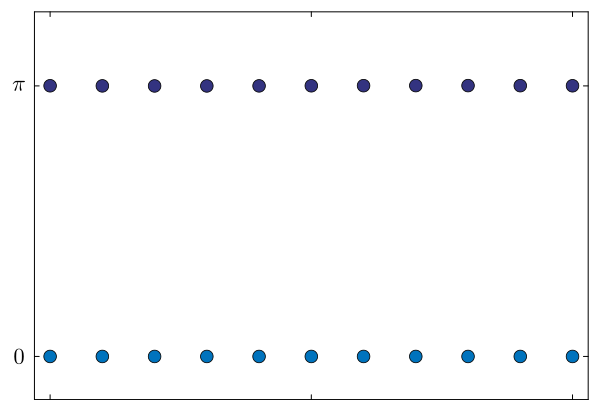

In [5]:
df = CSV.read("fig2b.csv", DataFrame)

kappalist = df.kappa_list
wilson_list = zeros(Float64, length(kappalist), 5)

wilson_list[:,1] = df.localized_1
wilson_list[:,2] = df.localized_2
wilson_list[:,3] = df.delocalized_1;
wilson_list[:,4] = df.delocalized_2;
wilson_list[:,5] = df.delocalized_3;

msdefined = 7

common_kwargs = (
    legend=false,
    label="exciton",
    ylim=(-0.5, 4),
    framestyle=:box,
    xticks=([0, 0.5, 1], []),
    yticks=([0, 3.14], [L"0", L"\pi"]),
    tickfontsize=15,
    xgrid=false,
    ygrid=false,
    ms=msdefined,
    ylabelfontsize=20,
    xlabelfontsize=20,
    bottom_margin=-3.9mm,
    markershape=marker_list_for_plot[1],
)

p_gs = scatter(kappalist, wilson_list[:, 1];
    color=color_list_for_plot[1], common_kwargs...)

scatter!(alphalist, wilson_list[:, 2];
    color=color_list_for_plot[2], common_kwargs...)


In [6]:
greenlist = wrap_to_pi.(wilson_list[:, 5])
greenlist[5:7] .= wrap_to_positive.(greenlist[5:7]) # phase is equivalent mod 2pi, here is just for visual clarity

msdefined = 7
yrange = (-3.5, 4.8)
p_excited = scatter(alphalist, wilson_list[:, 3],
    label="delocalized state # 2", ylim=yrange, legend=false,
    color=color_list_for_plot[3], framestyle=:box, xticks=([0, 0.5, 1]), yticks=([-pi,0, pi], [L"-\pi", L"0", L"\pi"]), markershape=marker_list_for_plot[3], tickfontsize=14,
    xgrid=false, ygrid=false, ms=msdefined,
    ylabelfontsize=17, xlabelfontsize=17)
scatter!(alphalist, wilson_list[:, 4], color=color_list_for_plot[4], markershape=marker_list_for_plot[4], markersize=msdefined,
    legendfontsize=6, ylim=yrange)
scatter!(alphalist, greenlist, color=color_list_for_plot[5], markershape=marker_list_for_plot[5], markersize=msdefined,
    legendfontsize=6, ylim=yrange, top_margin=-1.9mm)

x = [0.0, 0.1]
y = [wilson_list[:, 3][1], wilson_list[:, 3][2]]

# Compute slope and intercept
m = (y[2] - y[1]) / (x[2] - x[1])
b = y[1] - m * x[1]

x_extrap = LinRange(0.0, 1, 100)
y_extrap = m .* x_extrap .+ b

plot!(x_extrap, y_extrap, lw=1, color=color_list_for_plot[3], ls=:dash)

x = [0.0, 0.1]
y = [wrap_to_positive.(wilson_list[:, 4])[1], wrap_to_positive.(wilson_list[:, 4])[2]]

# Compute slope and intercept
m = (y[2] - y[1]) / (x[2] - x[1])
b = y[1] - m * x[1]


x_extrap = LinRange(0.0, 1, 100)
y_extrap = m .* x_extrap .+ b
plot!(x_extrap, y_extrap, lw=1, color=color_list_for_plot[4], ls=:dash)

x = [0.0, 0.1]
y = [wrap_to_pi.(wilson_list[:, 5])[1], wrap_to_pi.(wilson_list[:, 5])[2]]

# Compute slope and intercept
m = (y[2] - y[1]) / (x[2] - x[1])
b = y[1] - m * x[1]


x_extrap = LinRange(0.0, 1, 100)
y_extrap = m .* x_extrap .+ b
plot!(x_extrap, y_extrap, lw=1, color=color_list_for_plot[5], ls=:dash)

gr()
porigin = plot(p_gs, layout=(2, 1), index=1, dpi=800)
# Add the second plot to the bottom subplot (index 2)
plot!(porigin, p_excited, layout=(2, 1), index=2)
savefig("fig2b.pdf")

"/Users/xuyang/numerical_library/github/exciton/src/fig2/fig2b.pdf"

# Fig 2c

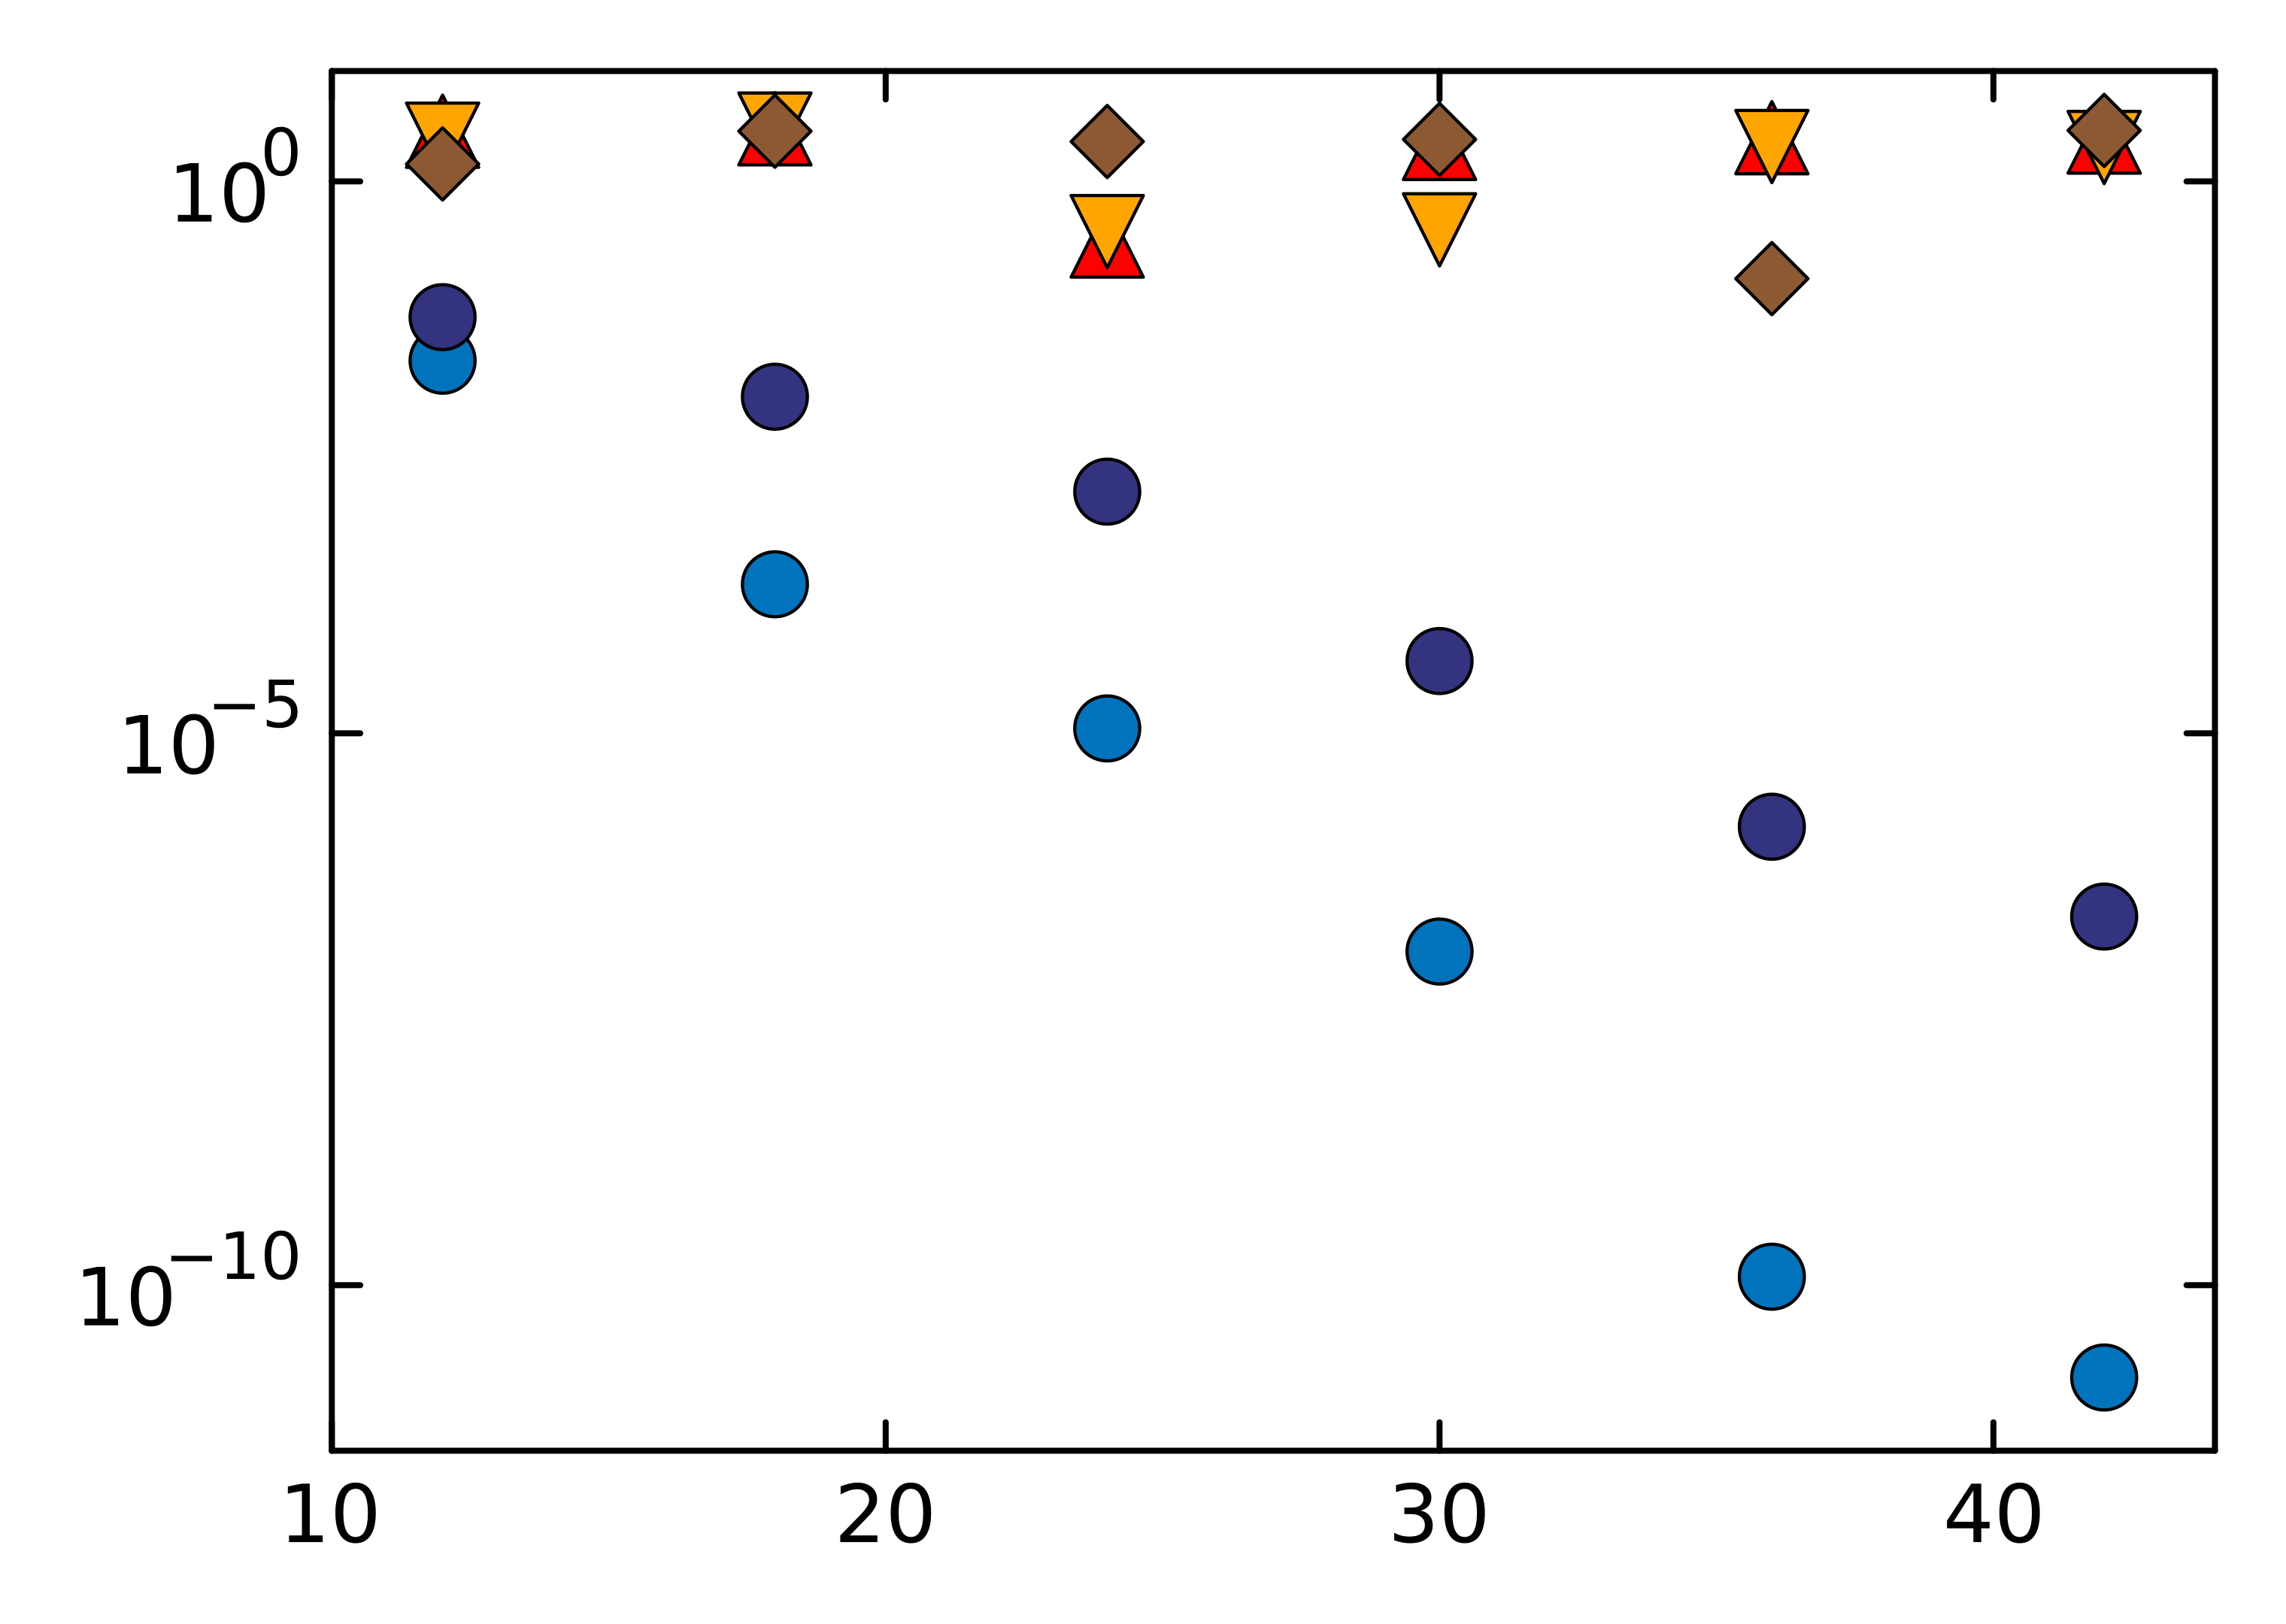

"/Users/xuyang/numerical_library/github/exciton/src/fig2/fig2c.pdf"

In [7]:
df = CSV.read("fig2c.csv", DataFrame)

Nsample_list = df.size_list
std_over_alpha = zeros(Float64, length(Nsample_list), 5)

std_over_alpha[:,1] = df.localized_1
std_over_alpha[:,2] = df.localized_2
std_over_alpha[:,3] = df.delocalized_1;
std_over_alpha[:,4] = df.delocalized_2;
std_over_alpha[:,5] = df.delocalized_3;

pp = scatter(Nsample_list,
    std_over_alpha[:, 1],
    yscale=:log10,
    framestyle=:box,
    xticks=([10, 20, 30, 40]),
    yticks=[1, 1e-5, 1e-10],
    tickfontsize=9,
    xgrid=false,
    ygrid=false,
    ms=6,
    label=false,
    ylabelfontsize=12,
    xlabelfontsize=12,
    dpi=800,
    size=(380, 270),
    color=color_list_for_plot[1], xlim=(10, 44), ylim=(10^(-11.5), 10))

for (j, c) in zip(2:2, color_list_for_plot[2:2])
    scatter!(Nsample_list, std_over_alpha[:, j], ms=6, label=false, color=c)
end

for (j, c, m) in zip(3:5, color_list_for_plot[3:5], marker_list_for_plot[3:5])
    scatter!(Nsample_list, std_over_alpha[:, j], ms=6, label=false, color=c, markershape=m)
end
display(pp)
savefig("fig2c.pdf")